In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import anndata as ad
import hdf5plugin

from scipy.stats import gamma, expon
from scipy import sparse

import importlib

from Prep_Data import pgrins_prepare_output

In [2]:
importlib.reload(mpl)
mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 10,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 10,            # axis-label size matches body text
    'xtick.labelsize'     : 9,             # tick labels one point smaller
    'ytick.labelsize'     : 9,
    'legend.fontsize'     : 9,             # legend text one point smaller
    
    #'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
    #    '#0072B2', '#D55E00', '#009E73',
    #    '#E69F00', '#CC79A7', '#56B4E9',
    #]),
    
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    'xtick.minor.size'    : 2,             # half of major — proportional
    'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 300,           # publication-quality resolution
})

prop_cycle = [c["color"] for c in list(mpl.rcParams["axes.prop_cycle"])]

# Import Data:

In [3]:
norman_data = sc.read_h5ad("Data/Experimental/Norman19/perturb_subset_Keggoro.h5ad")
replogle_data = sc.read_h5ad("Data/Experimental/Replogle22/perturb_subset_Keggoro.h5ad")

In [4]:
grins_data = sc.read_h5ad("Data/Projects/KeggoRo/perturb_norm.h5ad")

In [5]:
grins_data_2 = pgrins_prepare_output.apply_missingness(grins_data,inplace=False)

Calculate QC metrics...


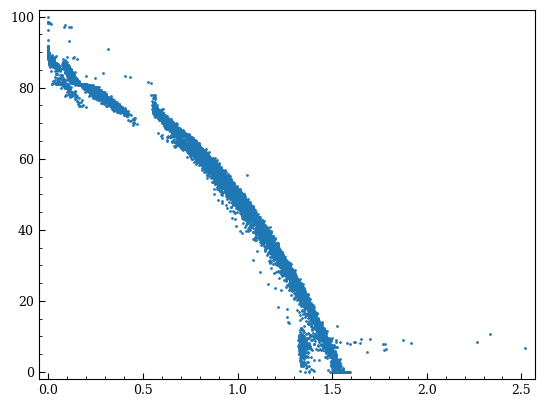

In [6]:
plt.scatter(grins_data_2.var.log1p_mean_counts,grins_data_2.var.pct_dropout_by_counts,s=1)

# Missingness Analysis:

## Across Cells:

In [12]:
from scipy import stats

In [21]:
import statsmodels.api as sm

In [26]:
np.asarray(cell_mean).squeeze()

array([0.18495244, 0.15834312, 0.1944184 , ..., 0.22339237, 0.22363055,
       0.1980267 ], shape=(97120,), dtype=float32)

In [30]:
stats.shapiro(np.asarray(cell_mean)[:100].squeeze())

ShapiroResult(statistic=np.float64(0.9783357654307713), pvalue=np.float64(0.09853517456348952))

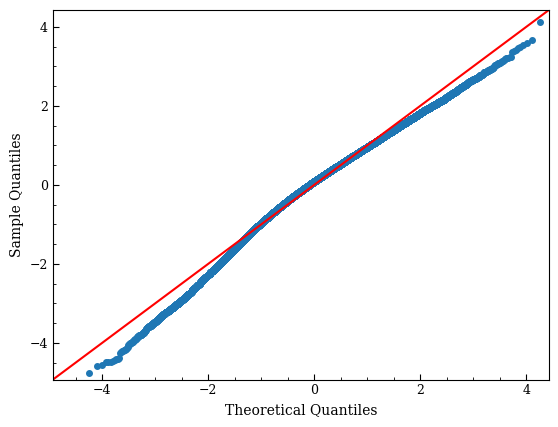

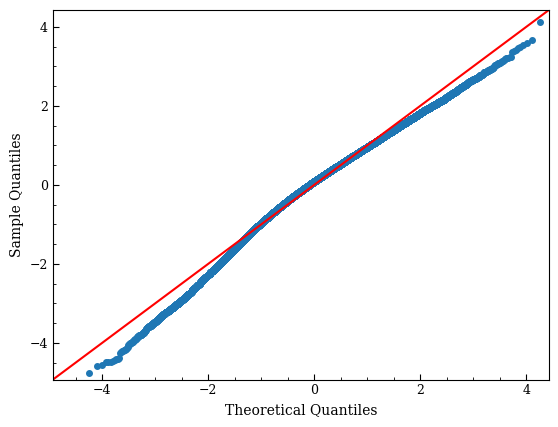

In [53]:
sm.qqplot(np.asarray(cell_mean).squeeze(),fit=True,line='45')

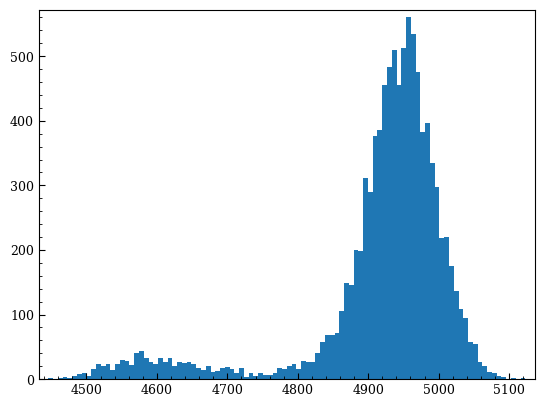

In [68]:
plt.hist(grins_data_2.obs["n_genes_by_counts"],bins=100)
plt.show()

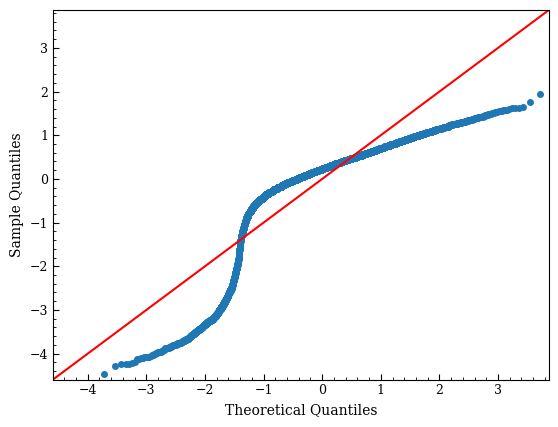

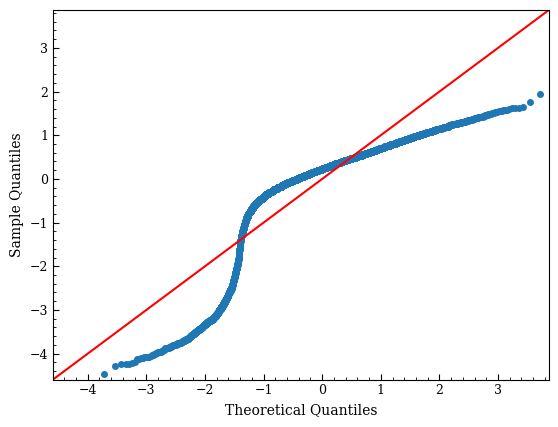

In [63]:
sm.qqplot((grins_data_2.obs["n_genes_by_counts"]),fit=True,line='45')

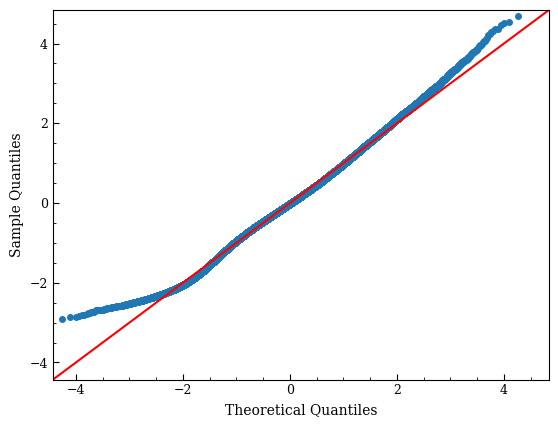

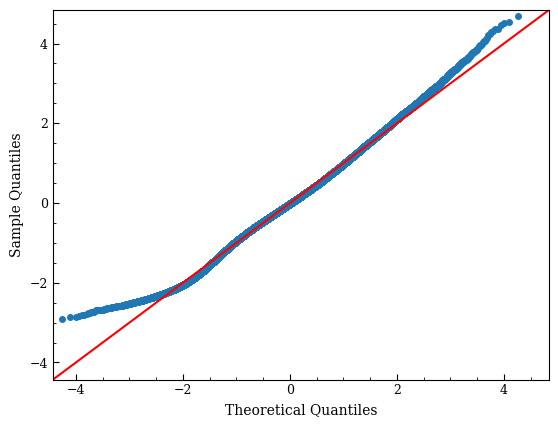

In [55]:
sm.qqplot((norman_data.obs["n_genes_by_counts"]),fit=True,line='45')

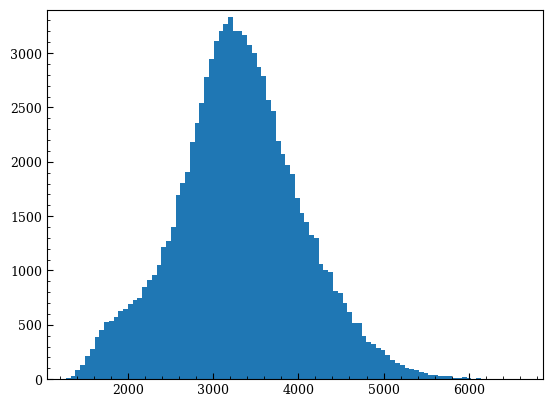

In [43]:
plt.hist(list(norman_data.obs["n_genes_by_counts"]),bins=100)
plt.show()

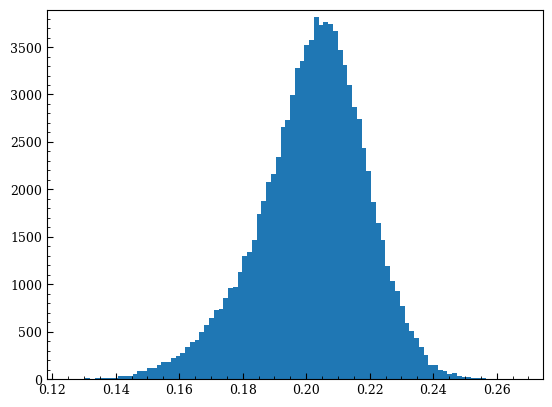

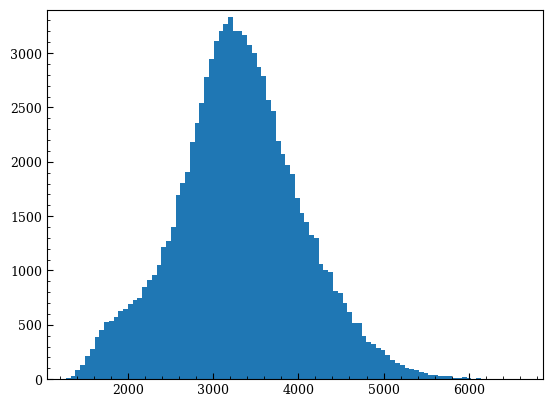

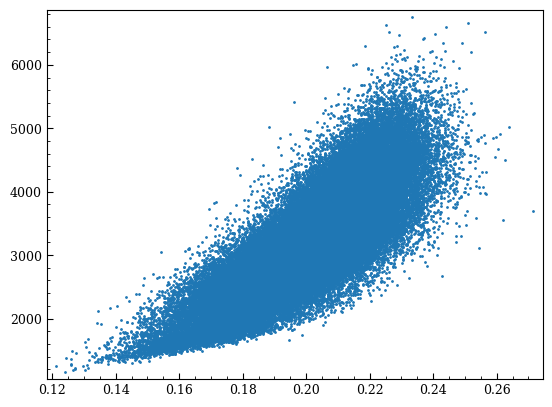

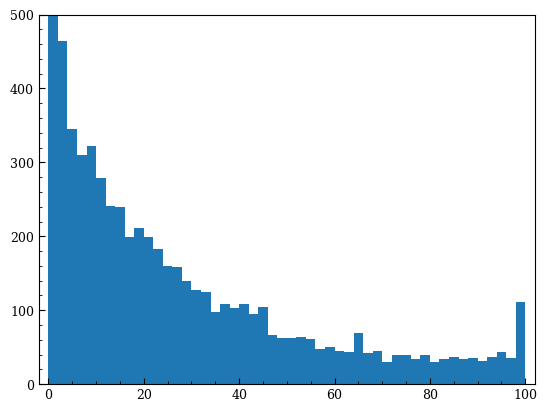

In [10]:
cell_mean = np.mean(norman_data.layers["log1p"],axis=1)
cell_counts = list(norman_data.obs.n_genes_by_counts)
plt.hist(cell_mean,bins=100)
plt.show()
plt.hist(cell_counts,bins=100) # Follows normal hist
plt.show()
plt.scatter(list(cell_mean),list(cell_counts),s=1)
plt.show()
plt.hist(list(100-norman_data.var["pct_dropout_by_counts"]),bins=50)
plt.ylim(0,500)
plt.show()

## Across Genes:

/tmp/ipykernel_519812/1569209916.py:14: RuntimeWarning: invalid value encountered in divide
  replogle_scaling_factor = np.nanmean(replogle_y/dense_replogle_y) # PDF was fitted on dense replogle, but for comparison of Norman & Replogle, actual counts are better -> scale PDF by this factor


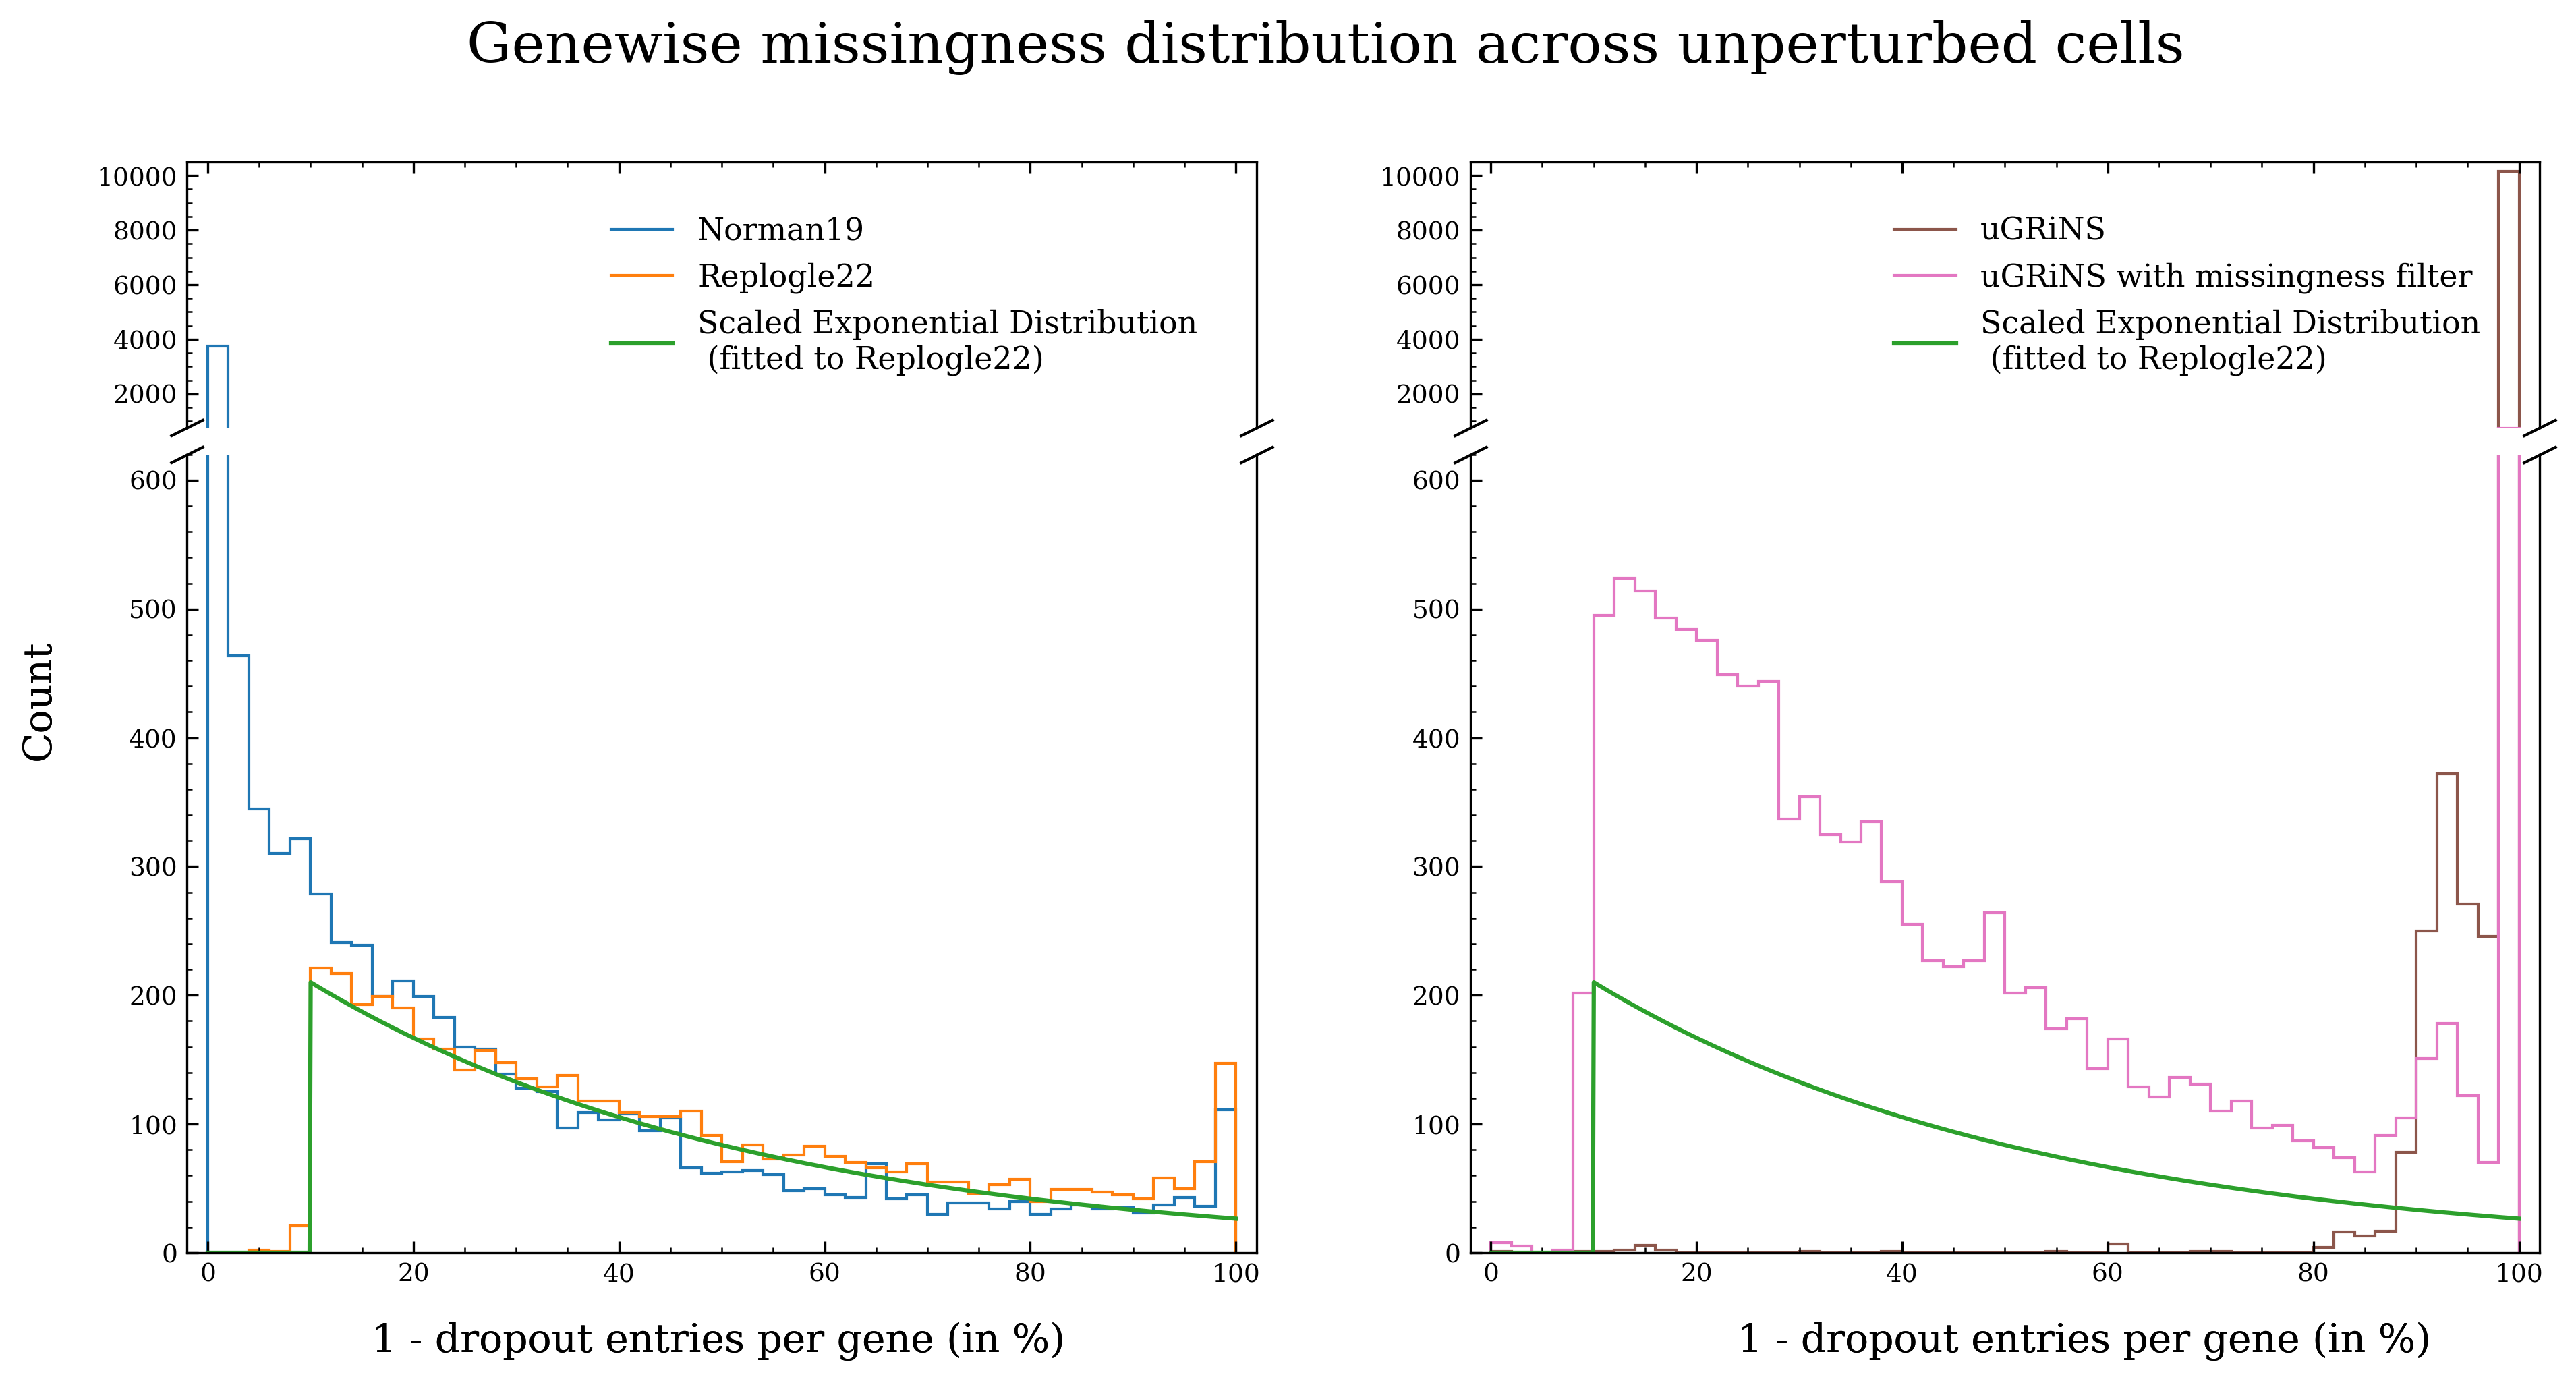

In [9]:
fig, axs = plt.subplots(2, 2, sharex="col",figsize=(15,7),dpi=300,height_ratios=[1,3])
fig.subplots_adjust(hspace=0.05)  # adjust space between Axes

bins = 50
replogle_y, replogle_x = np.histogram(list(100-replogle_data.var["pct_dropout_by_counts"]),bins=bins,range=(0,100))
norman_y, norman_x = np.histogram(list(100-norman_data.var["pct_dropout_by_counts"]),bins=bins,range=(0,100))

grins_y, grins_x = np.histogram(list(100-grins_data.var["pct_dropout_by_counts"]),bins=bins,range=(0,100))
miss_grins_y, miss_grins_x = np.histogram(list(100-grins_data_2.var["pct_dropout_by_counts"]),bins=bins,range=(0,100))

dense_replogle_y, dense_replogle_x = np.histogram(list(100-replogle_data.var["pct_dropout_by_counts"]),bins=bins,range=(0,100),density=True)
pdf_fitted = expon.pdf(np.linspace(0,100,1000),loc=10,scale=np.mean(100-replogle_data.var["pct_dropout_by_counts"]))

replogle_scaling_factor = np.nanmean(replogle_y/dense_replogle_y) # PDF was fitted on dense replogle, but for comparison of Norman & Replogle, actual counts are better -> scale PDF by this factor
for j in range(2):
    ax1 = axs[0,j]
    ax2 = axs[1,j]
    if j == 0:
        ax1.stairs(norman_y,norman_x,label="Norman19",color=prop_cycle[0])
        ax2.stairs(norman_y,norman_x,color=prop_cycle[0])

        ax1.stairs(replogle_y,replogle_x, label="Replogle22",color=prop_cycle[1])
        ax2.stairs(replogle_y,replogle_x,color=prop_cycle[1])
    else:
        ax1.stairs(grins_y,grins_x, label="uGRiNS",color=prop_cycle[5])
        ax2.stairs(grins_y,grins_x,color=prop_cycle[5])


        ax1.stairs(miss_grins_y,miss_grins_x, label="uGRiNS with missingness filter",color=prop_cycle[6])
        ax2.stairs(miss_grins_y,miss_grins_x,color=prop_cycle[6])

    ax2.plot(np.linspace(0,100,1000),replogle_scaling_factor*pdf_fitted,color=prop_cycle[2])
    ax1.plot(np.linspace(0,100,1000),replogle_scaling_factor*pdf_fitted,color=prop_cycle[2],label="Scaled Exponential Distribution \n (fitted to Replogle22)")

    ax2.set_ylim(0,620)
    ax1.set_ylim(750,10500)

    ax1.spines.bottom.set_visible(False)
    ax2.spines.top.set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # don't put tick labels at the top
    ax2.xaxis.tick_bottom()

    d = .5  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

    fig.text(0.3, 0.04, '1 - dropout entries per gene (in %)', ha='center',fontsize=14)
    fig.text(0.75, 0.04, '1 - dropout entries per gene (in %)', ha='center',fontsize=14)
    fig.text(0.07, 0.5, 'Count', va='center', rotation='vertical',fontsize=14)
    ax1.legend(loc="upper right",bbox_to_anchor=(0.98,0.9),fontsize=11)
    plt.suptitle("Genewise missingness distribution across unperturbed cells",fontsize=20)
plt.show()

# Clustering: